In [1]:
# Check current directory
!pwd

/workspaces/GWData-Bootcamp/2023/deep_learning/baseline


In [2]:
# Install necessary packages
!pip install --upgrade lalsuite # -i https://mirrors.aliyun.com/pypi/simple


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [3]:
# https://git.ligo.org/lscsoft/lalsuite/-/issues/300
import lal
lal.__version__

/tmp/ipykernel_10984/1428922197.py:2: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


'7.7.0'

In [4]:
import torch
torch.__version__

'2.7.1+cpu'

# PyTorch Deep Learning Framework

PyTorch is an open-source deep learning framework developed by Facebook’s AI Research (FAIR) team. It provides two key features:

1.	A powerful GPU-accelerated tensor computation library (similar to NumPy).
2.	Deep neural networks with an automatic differentiation system.

The design philosophy of PyTorch is to “give users as much control over the process as possible, rather than hiding complex details.”

This makes PyTorch highly flexible for research and developing new deep learning models, as users can observe and control the internal operations of the models.

- This part of the code mainly imports the required libraries.

In [33]:
# Load all related packages, classes, and functions used in the script
from main import *
from utils import *

- Example

In [77]:
dets = ['H1', 'L1']
ndet = len(dets)
fs = 8192 # Hz
T_obs = 1 # second

psds = [gen_psd(fs,T_obs,op='AdvDesign',det=d) for d in dets]

# generate a single new timeseries and chirpmass
mdist='astro'
beta=[0.75,0.95]
verbose=False
snr = 17.0
par_new = gen_par(fs,T_obs,mdist=mdist,beta=beta,verbose=verbose)
ts_new,_,_ = gen_bbh(fs,T_obs,psds,snr=snr,dets=dets,beta=beta,par=par_new,verbose=verbose)

# generate noise and whitened data
ts_noise = np.array([gen_noise(fs,T_obs,psd.data.data) for psd in psds]).reshape(ndet,-1)
data = np.array([whiten_data(t,T_obs,fs,psd.data.data) for t,psd in zip(ts_noise+ts_new,psds)]).reshape(ndet,-1)
signal = np.array([whiten_data(t,T_obs,fs,psd.data.data) for t,psd in zip(ts_new,psds)]).reshape(ndet,-1)

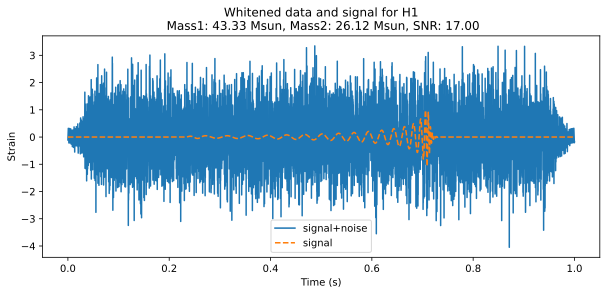

In [81]:
time = np.linspace(0, T_obs, fs*T_obs)
for i, det in enumerate(dets):
    plt.figure(figsize=(10,4))
    plt.title(f'Whitened data and signal for {det}\n Mass1: {float(par_new.m1):.2f} Msun, Mass2: {float(par_new.m2):.2f} Msun, SNR: {snr:.2f}')
    plt.plot(time, data[i], label=f'signal+noise')
    plt.plot(time, signal[i], label=f'signal', linestyle='--')
    plt.xlabel('Time (s)')
    plt.ylabel('Strain')
    plt.legend()
    plt.show()
    break

## Train

- This code is an example of a binary classification task using PyTorch, where the goal is to classify gravitational wave data (signal + noise).

- First, we create a data generator DatasetGenerator, which is used to generate the training and testing datasets. Each epoch contains 100 samples, with a signal-to-noise ratio of 20.

- Next, we use PyTorch’s DataLoader to create training and testing data loaders with a batch size of 32. The data is shuffled after each epoch.

- Then, we load a pre-trained model. If no pre-trained model exists, a new model is initialized. The output paths for the model and loss history are set to `./checkpoints_cnn/`.

- After that, we set the optimizer parameters: a learning rate of 0.003 and a total of 100 training epochs. If a pre-trained model is used, the number of training epochs is added to the number of epochs already trained.

- Finally, we call the train function to start training the model. During training, the model is evaluated on the test set after each epoch, and the model with the lowest test loss is saved.

loss 0.0080, train acc 0.890, test acc 1.000
66.0 examples/sec on cpu


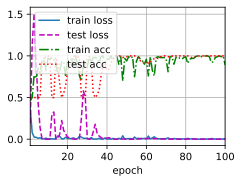

In [ ]:
# Initialize the data generation class
nsample_perepoch = 100  # Number of samples per epoch
dataset_train = DatasetGenerator(snr=20, nsample_perepoch=nsample_perepoch)  # Training dataset
dataset_test = DatasetGenerator(snr=20, nsample_perepoch=nsample_perepoch)  # Testing dataset

# Create a DataLoader
data_loader = DataLoader(dataset_train, batch_size=32, shuffle=True,)  # Training data loader
test_iter = DataLoader(dataset_test, batch_size=32, shuffle=True,)  # Testing data loader

# device = torch.device('cuda')  # Use CUDA device
device = torch.device('cpu')  # Use CPU device

# Output path for the model and loss history
checkpoint_dir = './checkpoints_cnn/'

# Create the model
net, epoch, train_loss_history = load_model(checkpoint_dir)  # Load model
net.to(device);  # Move the model to the device

# Optimizer parameters
lr = 0.003  # Learning rate
total_epochs = 100  # Total number of training epochs
total_epochs += epoch  # Add previously trained epochs
output_freq = 1  # Output frequency

# Train the model
train(net, lr, nsample_perepoch, epoch, total_epochs,
      dataset_train, data_loader, test_iter,
      train_loss_history, checkpoint_dir, device, notebook=True)

# It may take 12min for 100 epochs on CPU

In [8]:
dataset_train.strains.shape

(100, 1, 2, 16384)

## Evaluate

This code defines a function evaluate_gpu that computes the model’s predictions on a dataset using a GPU.

- First, we check whether the input model net is an instance of nn.Module. If it is, we set the model to evaluation mode and get the device of the model. If the user does not specify a device, we use the device of the model’s first parameter.

- Next, we define a softmax function to convert the model’s outputs into probabilities.

- Then, we create two empty lists, y_hat_list and y_list, to store the model’s predictions and the true labels.

- After that, we enter a no-gradient computation context and iterate over all batches in the data loader data_iter. For each batch, we move the data and labels to the device and convert them to the appropriate data types. We then perform a forward pass through the model to obtain predictions.

- Next, we apply the softmax function to the predictions to obtain probabilities, move them to the CPU, convert them to NumPy arrays, extract the probabilities for the positive class, and convert them to a list. The labels are also moved to the CPU, converted to NumPy arrays, and then to a list.

- Finally, we append the predictions and labels to y_hat_list and y_list. After iterating over all batches, these two lists are converted to NumPy arrays and returned.

This function can be used to evaluate the model’s performance on a validation or test set either after each epoch during training or after training is complete.

In [9]:
# Import necessary libraries
import lal  # https://git.ligo.org/lscsoft/lalsuite/-/issues/300
from main import *
from utils import *
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve

def evaluate_gpu(net, data_iter, device=None):
    """Compute model predictions on a dataset using GPU"""
    if isinstance(net, nn.Module):
        net.eval()  # Set to evaluation mode
        if not device:
            device = next(iter(net.parameters())).device  # Get device information
    softmax = nn.Softmax(dim=-1)  # Define softmax function; dim=-1 applies softmax along the last dimension
    y_hat_list = []  # Initialize prediction list
    y_list = []  # Initialize label list
    with torch.no_grad():  # Disable gradient computation
        for X, y in data_iter:  # Iterate over the dataset
            X = X.to(device).to(torch.float)  # Move data to device and convert to float
            y = y.to(device).to(torch.long)  # Move labels to device and convert to long
            y_hat = net(X)  # Make predictions using the model

            preds = softmax(y_hat).cpu().numpy()[:,1].tolist()  # Apply softmax to predictions and convert to list
            labels = y.cpu().numpy().tolist()  # Convert labels to list

            y_hat_list.extend(preds)  # Append predictions to the prediction list
            y_list.extend(labels)  # Append labels to the label list
    return np.asarray(y_hat_list), np.asarray(y_list)  # Return predictions and labels as NumPy arrays

The following code is an example of a binary classification task using PyTorch, where the goal is to classify gravitational wave data (signal + noise).

First, we create a data generator DatasetGenerator, which is used to generate the test dataset. Each epoch contains 1000 samples, with a signal-to-noise ratio of 20.

Next, we use PyTorch’s DataLoader to create the test data loader with a batch size of 32. The data is shuffled after each epoch.

In [10]:
nsample_perepoch = 1000 # num of injections
snr = 20  # signal-to-noise ratio

dataset_test = DatasetGenerator(snr=snr, nsample_perepoch=nsample_perepoch)
data_iter = DataLoader(dataset_test, batch_size=32, shuffle=True,)

GPU available? False


Next, we load a pre-trained model. If no pre-trained model exists, a new model is initialized. The output path for the model and loss history is `./checkpoints_cnn/`.

In [11]:
# load model
# device = torch.device('cuda')
device = torch.device('cpu')

# Where we output our model and loss history
checkpoint_dir = './checkpoints_cnn/'

# Creat model
net, epoch, train_loss_history = load_model(checkpoint_dir)
net.to(device);

Load network from checkpoints_cnn/model_e98.pt


Then, we call the evaluate_gpu function to make predictions on the test dataset, obtaining both the predicted results and the true labels.



In [12]:
y_hat_list, y_list = evaluate_gpu(net, data_iter, device)

Next, we use the roc_curve and roc_auc_score functions to compute the ROC curve and the AUC value.



In [13]:
fpr, tpr, thresholds = roc_curve(y_list, y_hat_list)
auc = roc_auc_score(y_list, y_hat_list)
auc

0.9941479999999999

After that, we plot the ROC curve and mark the point corresponding to a threshold of 0.5.

In [14]:
index = np.argmax(thresholds < 0.5)

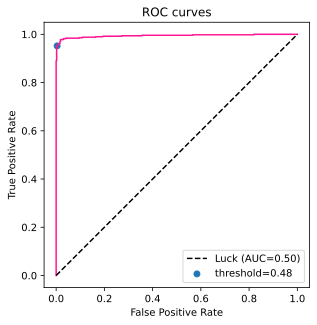

In [15]:
plt.plot(fpr, tpr, color="deeppink")
plt.plot(*(np.linspace(0,1,100),)*2, 'k--', label='Luck (AUC=0.50)')
plt.scatter(fpr[index], tpr[index], label=f'threshold={thresholds[index]:.2f}')
plt.axis("square")
# plt.xscale('log')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves")
plt.legend()
plt.show()

Finally, we test the model under different signal-to-noise ratios (SNRs), plot the ROC curves for each SNR, and calculate their AUC values.

  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [01:27<00:00, 21.96s/it]


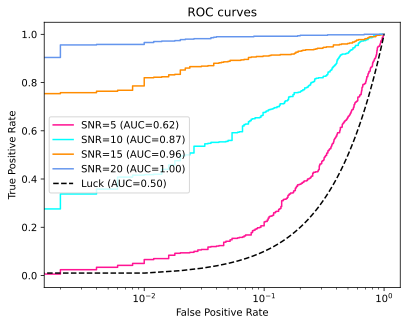

In [16]:
from itertools import cycle
colors = cycle(["deeppink", "aqua", "darkorange", "cornflowerblue"])

nsample_perepoch = 1000
snr_list = [5, 10, 15, 20]
for snr in tqdm(snr_list):
    dataset_test = DatasetGenerator(snr=snr, nsample_perepoch=nsample_perepoch, verbose=False)
    data_iter = DataLoader(dataset_test, batch_size=32, shuffle=True)
    y_hat_list, y_list = evaluate_gpu(net, data_iter, device)

    fpr, tpr, thresholds = roc_curve(y_list, y_hat_list)
    auc = roc_auc_score(y_list, y_hat_list)
    
    plt.plot(fpr, tpr, color=next(colors), label=f'SNR={snr} (AUC={auc:.2f})')
plt.plot(*(np.linspace(0,1,100),)*2, 'k--', label='Luck (AUC=0.50)')
# plt.axis("square")
plt.xscale('log')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves")
plt.legend()
plt.show()

In the last part, we compute the errors for the ROC curves and plot the ROC curves with error bars.

This code demonstrates how to perform a binary classification task using PyTorch and evaluate the model using ROC curves and AUC values.

It also shows how to test the model under different SNRs and how to compute and plot ROC curves with error bars.

  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [01:03<00:00, 21.20s/it]


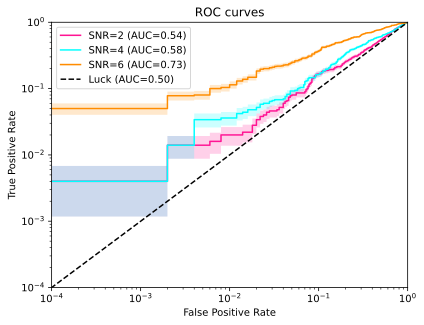

In [17]:
from itertools import cycle
colors = cycle(["deeppink", "aqua", "darkorange", "cornflowerblue"])

def sigma(n, tp):
    """

    :param tp:
    :param n:
    :return:
    """
    return np.sqrt(tp*(1.-tp)/n)

nsample_perepoch = 1000
snr_list = [2, 4, 6]
for snr in tqdm(snr_list):
    dataset_test = DatasetGenerator(snr=snr, nsample_perepoch=nsample_perepoch, verbose=False)
    data_iter = DataLoader(dataset_test, batch_size=32, shuffle=True)
    y_hat_list, y_list = evaluate_gpu(net, data_iter, device)

    fpr, tpr, _ = roc_curve(y_list, y_hat_list)
    auc = roc_auc_score(y_list, y_hat_list)
    
    fpr_error = [sigma(len(y_list)/2., t) for t in fpr]
    tpr_error = [sigma(len(y_list)/2., t) for t in tpr]
    
    color = next(colors)
    plt.plot(fpr, tpr, color=color, label=f'SNR={snr} (AUC={auc:.2f})')
    plt.fill_between(fpr, tpr+tpr_error, tpr-tpr_error, alpha=0.2, facecolor=color, zorder=0)
plt.plot(*(np.linspace(0,1,100),)*2, 'k--', label='Luck (AUC=0.50)')
# plt.axis("square")
plt.xscale('log')
plt.yscale('log')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves")
plt.xlim(1e-4,1)
plt.ylim(1e-4,1)
plt.legend()
plt.show()